#### Madness Website


# March Madness Tournament Prediction Model

This notebook provides a comprehensive solution for predicting NCAA March Madness tournament outcomes. It includes the following steps:

1. **Setup**: Import necessary libraries and set up the environment, including creating directories for data, models, and results.

2. **Data Loading and Processing**: Define functions to load and process the NCAA basketball data from CSV files. This includes loading teams, regular season results, tournament results, seeds, rankings, and conference data.

3. **Feature Engineering**: Define functions to extract and engineer features for the prediction model. This includes calculating team statistics, extracting seed numbers, getting team rankings, and creating matchup features.

4. **Model Training and Evaluation**: Define functions to train and evaluate the prediction model. This includes training a gradient boosting model, performing hyperparameter tuning, saving and loading the model, and evaluating model performance on historical tournament data.

5. **Tournament Prediction**: Define functions to generate predictions for the NCAA tournament. This includes preparing potential matchups for the current tournament season, predicting the outcome of specific matchups, and simulating the tournament multiple times to get expected outcomes.

6. **Training the Model**: Prepare the training data using historical tournament data and train the prediction model. The trained model is then saved for future use, and its performance is evaluated on all available data.

By following these steps, the notebook aims to build a robust model for predicting the outcomes of NCAA March Madness tournament games and simulate the tournament to estimate the probabilities of different teams advancing through the rounds and winning the championship.

# March Madness Tournament Prediction Model

This notebook provides a comprehensive solution for predicting NCAA March Madness tournament outcomes. It includes:
- Data loading and processing
- Feature engineering
- Model training and evaluation
- Tournament simulation and prediction
- Visualization and analysis of results

## Setup

First, let's import the necessary libraries and set up our environment.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import log_loss, roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from tqdm.notebook import tqdm

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Configuration
DATA_DIR = "data/"  # Directory containing NCAA CSV files
MODEL_DIR = "models/"  # Directory for saving models
RESULTS_DIR = "results/"  # Directory for saving results

# Create directories if they don't exist
for directory in [DATA_DIR, MODEL_DIR, RESULTS_DIR]:
    os.makedirs(directory, exist_ok=True)

print("Setup complete!")

Setup complete!


# 1. Data Loading and Processing

Let's define functions to load and process the NCAA basketball data.

In [2]:
def load_data(data_dir):
    """
    Load all necessary datasets from the provided directory.
    """
    # Load teams data
    teams = pd.read_csv(os.path.join(data_dir, "MTeams.csv"))
    
    # Load regular season results
    regular_season = pd.read_csv(os.path.join(data_dir, "MRegularSeasonCompactResults.csv"))
    detailed_regular_season = pd.read_csv(os.path.join(data_dir, "MRegularSeasonDetailedResults.csv"))
    
    # Load tournament data
    tourney_results = pd.read_csv(os.path.join(data_dir, "MNCAATourneyCompactResults.csv"))
    tourney_seeds = pd.read_csv(os.path.join(data_dir, "MNCAATourneySeeds.csv"))
    
    # Load rankings data
    rankings = pd.read_csv(os.path.join(data_dir, "MMasseyOrdinals.csv"))
    
    # Load conference data
    conferences = pd.read_csv(os.path.join(data_dir, "MTeamConferences.csv"))
    
    return {
        'teams': teams,
        'regular_season': regular_season,
        'detailed_regular_season': detailed_regular_season,
        'tourney_results': tourney_results,
        'tourney_seeds': tourney_seeds,
        'rankings': rankings,
        'conferences': conferences
    }

# Load the data
try:
    data = load_data("C:\\Users\\JonMa\\OneDrive\\portfolio\\Madness\\data_dir")
    print("Data loaded successfully!")
    
    # Display basic information about the datasets
    print("\nDataset Information:")
    for name, df in data.items():
        print(f"{name}: {df.shape[0]} rows x {df.shape[1]} columns")
    
    # Show sample of teams data
    print("\nSample of teams data:")
    display(data['teams'].head())
    
except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    print("Please make sure all required CSV files are in the data directory.")

Data loaded successfully!

Dataset Information:
teams: 380 rows x 4 columns
regular_season: 191796 rows x 8 columns
detailed_regular_season: 117748 rows x 34 columns
tourney_results: 2518 rows x 8 columns
tourney_seeds: 2558 rows x 3 columns
rankings: 5489117 rows x 5 columns
conferences: 13388 rows x 3 columns

Sample of teams data:


,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2025
1,1102,Air Force,1985,2025
2,1103,Akron,1985,2025
3,1104,Alabama,1985,2025
4,1105,Alabama A&M,2000,2025


# 2. Feature Engineering

Now let's define functions to extract and engineer features for our prediction model.


In [3]:
def extract_seed_number(seed_string):
    """
    Extract numeric seed (1-16) from seed string like 'W01' or 'X16'
    """
    return int(seed_string[1:3])

def get_team_seed(tourney_seeds, season, team_id):
    """
    Get the seed for a team in a specific season.
    Returns the numeric seed (1-16) or 0 if not found.
    """
    seed_row = tourney_seeds[(tourney_seeds['Season'] == season) & 
                            (tourney_seeds['TeamID'] == team_id)]
    
    if len(seed_row) == 0:
        return 0
    
    seed_string = seed_row.iloc[0]['Seed']
    return extract_seed_number(seed_string)

def get_team_rankings(rankings, season, team_id, day_num=133):
    """
    Get the rankings for a team before the tournament in a specific season.
    Returns a dictionary of rankings from different systems.
    """
    # Filter for the given season, team, and before tournament
    team_rankings = rankings[(rankings['Season'] == season) & 
                           (rankings['TeamID'] == team_id) &
                           (rankings['RankingDayNum'] < day_num)]
    
    if len(team_rankings) == 0:
        return {'avg_rank': 0}
    
    # Get the latest rankings before the tournament
    max_day = team_rankings['RankingDayNum'].max()
    latest_rankings = team_rankings[team_rankings['RankingDayNum'] == max_day]
    
    # Calculate average ranking
    avg_rank = latest_rankings['OrdinalRank'].mean()
    
    # Prepare the result dictionary
    result = {'avg_rank': avg_rank}
    
    # Add rankings from specific systems if available
    for system in ['POM', 'SAG', 'MOR', 'DOK', 'RPI']:
        system_rank = latest_rankings[latest_rankings['SystemName'] == system]
        if len(system_rank) > 0:
            result[f'{system.lower()}_rank'] = system_rank.iloc[0]['OrdinalRank']
        else:
            result[f'{system.lower()}_rank'] = 0
    
    return result

def calculate_team_season_stats(regular_season, detailed_regular_season, season, team_id):
    """
    Calculate comprehensive statistics for a team in a specific season.
    """
    # Basic stats from compact results
    team_games = regular_season[(regular_season['Season'] == season) & 
                              ((regular_season['WTeamID'] == team_id) | 
                               (regular_season['LTeamID'] == team_id))]
    
    if len(team_games) == 0:
        return None
    
    # Calculate win-loss record
    wins = team_games[team_games['WTeamID'] == team_id]
    losses = team_games[team_games['LTeamID'] == team_id]
    
    num_games = len(team_games)
    num_wins = len(wins)
    win_pct = num_wins / num_games if num_games > 0 else 0
    
    # Calculate scoring statistics
    points_scored = wins['WScore'].sum() + losses['LScore'].sum()
    points_allowed = wins['LScore'].sum() + losses['WScore'].sum()
    
    avg_points_scored = points_scored / num_games if num_games > 0 else 0
    avg_points_allowed = points_allowed / num_games if num_games > 0 else 0
    scoring_margin = avg_points_scored - avg_points_allowed
    
    # Get detailed stats if available
    detailed_stats = {}
    if detailed_regular_season is not None:
        detailed_team_games = detailed_regular_season[
            (detailed_regular_season['Season'] == season) & 
            ((detailed_regular_season['WTeamID'] == team_id) | 
             (detailed_regular_season['LTeamID'] == team_id))
        ]
        
        if len(detailed_team_games) > 0:
            # Wins detailed stats
            detailed_wins = detailed_team_games[detailed_team_games['WTeamID'] == team_id]
            detailed_losses = detailed_team_games[detailed_team_games['LTeamID'] == team_id]
            
            # Offensive stats
            fg_made = detailed_wins['WFGM'].sum() + detailed_losses['LFGM'].sum()
            fg_attempted = detailed_wins['WFGA'].sum() + detailed_losses['LFGA'].sum()
            fg_pct = fg_made / fg_attempted if fg_attempted > 0 else 0
            
            fg3_made = detailed_wins['WFGM3'].sum() + detailed_losses['LFGM3'].sum()
            fg3_attempted = detailed_wins['WFGA3'].sum() + detailed_losses['LFGA3'].sum()
            fg3_pct = fg3_made / fg3_attempted if fg3_attempted > 0 else 0
            
            ft_made = detailed_wins['WFTM'].sum() + detailed_losses['LFTM'].sum()
            ft_attempted = detailed_wins['WFTA'].sum() + detailed_losses['LFTA'].sum()
            ft_pct = ft_made / ft_attempted if ft_attempted > 0 else 0
            
            # Rebounding
            off_rebounds = detailed_wins['WOR'].sum() + detailed_losses['LOR'].sum()
            def_rebounds = detailed_wins['WDR'].sum() + detailed_losses['LDR'].sum()
            total_rebounds = off_rebounds + def_rebounds
            
            # Other stats
            assists = detailed_wins['WAst'].sum() + detailed_losses['LAst'].sum()
            turnovers = detailed_wins['WTO'].sum() + detailed_losses['LTO'].sum()
            steals = detailed_wins['WStl'].sum() + detailed_losses['LStl'].sum()
            blocks = detailed_wins['WBlk'].sum() + detailed_losses['LBlk'].sum()
            
            # Opponent stats
            opp_fg_made = detailed_wins['LFGM'].sum() + detailed_losses['WFGM'].sum()
            opp_fg_attempted = detailed_wins['LFGA'].sum() + detailed_losses['WFGA'].sum()
            opp_fg_pct = opp_fg_made / opp_fg_attempted if opp_fg_attempted > 0 else 0
            
            opp_fg3_made = detailed_wins['LFGM3'].sum() + detailed_losses['WFGM3'].sum()
            opp_fg3_attempted = detailed_wins['LFGA3'].sum() + detailed_losses['WFGA3'].sum()
            opp_fg3_pct = opp_fg3_made / opp_fg3_attempted if opp_fg3_attempted > 0 else 0
            
            # Calculate per-game averages
            detailed_stats = {
                'fg_pct': fg_pct,
                'fg3_pct': fg3_pct,
                'ft_pct': ft_pct,
                'avg_off_rebounds': off_rebounds / num_games,
                'avg_def_rebounds': def_rebounds / num_games,
                'avg_total_rebounds': total_rebounds / num_games,
                'avg_assists': assists / num_games,
                'avg_turnovers': turnovers / num_games,
                'avg_steals': steals / num_games,
                'avg_blocks': blocks / num_games,
                'opp_fg_pct': opp_fg_pct,
                'opp_fg3_pct': opp_fg3_pct,
                'assist_to_turnover': assists / turnovers if turnovers > 0 else 0,
                'turnover_margin': (detailed_wins['LTO'].sum() + detailed_losses['WTO'].sum() - turnovers) / num_games
            }
            
            # Calculate advanced metrics
            possessions = (fg_attempted - off_rebounds + turnovers - 0.4 * ft_attempted) / num_games
            opp_possessions = (opp_fg_attempted - (detailed_wins['LOR'].sum() + detailed_losses['WOR'].sum()) + 
                              (detailed_wins['LTO'].sum() + detailed_losses['WTO'].sum()) - 
                              0.4 * (detailed_wins['LFTA'].sum() + detailed_losses['WFTA'].sum())) / num_games
            
            avg_possessions = (possessions + opp_possessions) / 2
            
            offensive_efficiency = 100 * (points_scored / (avg_possessions * num_games))
            defensive_efficiency = 100 * (points_allowed / (avg_possessions * num_games))
            
            detailed_stats.update({
                'offensive_efficiency': offensive_efficiency,
                'defensive_efficiency': defensive_efficiency,
                'efficiency_margin': offensive_efficiency - defensive_efficiency
            })
    
    # Combine all stats
    base_stats = {
        'team_id': team_id,
        'season': season,
        'num_games': num_games,
        'num_wins': num_wins,
        'win_pct': win_pct,
        'avg_points_scored': avg_points_scored,
        'avg_points_allowed': avg_points_allowed,
        'scoring_margin': scoring_margin
    }
    
    return {**base_stats, **detailed_stats}

def create_matchup_features(team_a_stats, team_a_ranking, team_a_seed,
                          team_b_stats, team_b_ranking, team_b_seed):
    """
    Create features for a matchup between two teams.
    """
    if team_a_stats is None or team_b_stats is None:
        return None
    
    # Basic differentials
    features = {
        'seed_diff': team_a_seed - team_b_seed,
        'win_pct_diff': team_a_stats['win_pct'] - team_b_stats['win_pct'],
        'scoring_margin_diff': team_a_stats['scoring_margin'] - team_b_stats['scoring_margin'],
        'avg_points_scored_diff': team_a_stats['avg_points_scored'] - team_b_stats['avg_points_scored'],
        'avg_points_allowed_diff': team_a_stats['avg_points_allowed'] - team_b_stats['avg_points_allowed'],
        'avg_rank_diff': team_a_ranking['avg_rank'] - team_b_ranking['avg_rank']
    }
    
    # Add detailed stats differentials if available
    for stat in ['fg_pct', 'fg3_pct', 'ft_pct', 'avg_off_rebounds', 'avg_def_rebounds',
                'avg_total_rebounds', 'avg_assists', 'avg_turnovers', 'avg_steals',
                'avg_blocks', 'opp_fg_pct', 'opp_fg3_pct', 'assist_to_turnover',
                'turnover_margin', 'offensive_efficiency', 'defensive_efficiency',
                'efficiency_margin']:
        if stat in team_a_stats and stat in team_b_stats:
            features[f'{stat}_diff'] = team_a_stats[stat] - team_b_stats[stat]
    
    # Add specific ranking differentials if available
    for system in ['pom', 'sag', 'mor', 'dok', 'rpi']:
        if f'{system}_rank' in team_a_ranking and f'{system}_rank' in team_b_ranking:
            features[f'{system}_rank_diff'] = team_a_ranking[f'{system}_rank'] - team_b_ranking[f'{system}_rank']
    
    # Calculate interaction features
    features['seed_win_pct_interaction'] = features['seed_diff'] * features['win_pct_diff']
    features['seed_margin_interaction'] = features['seed_diff'] * features['scoring_margin_diff']
    
    # Calculate seed-based features
    # Higher seeds (lower numbers) historically perform better
    features['higher_seed'] = 1 if team_a_seed < team_b_seed else 0
    features['seed_diff_squared'] = features['seed_diff'] ** 2
    
    # Calculate upset potential features
    if 'efficiency_margin' in team_a_stats and 'efficiency_margin' in team_b_stats:
        features['upset_potential'] = abs(features['seed_diff']) * (1 - abs(features['efficiency_margin_diff']))
    
    return features

def prepare_tournament_data(data, start_season=2010, end_season=2024):
    """
    Prepare data for tournament matchups from start_season to end_season.
    """
    tourney_results = data['tourney_results']
    tourney_seeds = data['tourney_seeds']
    rankings = data['rankings']
    regular_season = data['regular_season']
    detailed_regular_season = data['detailed_regular_season']
    
    # Filter for the relevant seasons
    tourney_games = tourney_results[(tourney_results['Season'] >= start_season) & 
                                    (tourney_results['Season'] <= end_season)]
    
    # Prepare features for each tournament game
    features_list = []
    for _, game in tourney_games.iterrows():
        season = game['Season']
        team_a_id = game['WTeamID']
        team_b_id = game['LTeamID']
        
        # Get team statistics
        team_a_stats = calculate_team_season_stats(regular_season, detailed_regular_season, season, team_a_id)
        team_b_stats = calculate_team_season_stats(regular_season, detailed_regular_season, season, team_b_id)
        
        # Get team rankings
        team_a_ranking = get_team_rankings(rankings, season, team_a_id)
        team_b_ranking = get_team_rankings(rankings, season, team_b_id)
        
        # Get team seeds
        team_a_seed = get_team_seed(tourney_seeds, season, team_a_id)
        team_b_seed = get_team_seed(tourney_seeds, season, team_b_id)
        
        # Create matchup features
        matchup_features = create_matchup_features(
            team_a_stats, team_a_ranking, team_a_seed,
            team_b_stats, team_b_ranking, team_b_seed
        )
        
        if matchup_features is not None:
            # Add game identifier and result
            matchup_features['season'] = season
            matchup_features['team_a_id'] = team_a_id
            matchup_features['team_b_id'] = team_b_id
            matchup_features['result'] = 1  # team_a won
            
            features_list.append(matchup_features)
            
            # Create reversed matchup features (symmetry for training)
            reversed_matchup_features = create_matchup_features(
                team_b_stats, team_b_ranking, team_b_seed,
                team_a_stats, team_a_ranking, team_a_seed
            )
            
            if reversed_matchup_features is not None:
                reversed_matchup_features['season'] = season
                reversed_matchup_features['team_a_id'] = team_b_id
                reversed_matchup_features['team_b_id'] = team_a_id
                reversed_matchup_features['result'] = 0  # team_a lost
                
                features_list.append(reversed_matchup_features)
    
    # Convert to DataFrame
    features_df = pd.DataFrame(features_list)
    
    return features_df

# 3. Model Training and Evaluation

Now let's define functions to train and evaluate our prediction model.

In [4]:
def train_model(features_df, test_size=0.2, random_state=42):
    """
    Train a gradient boosting model on the provided features.
    """
    # Separate features and target
    X = features_df.drop(['season', 'team_a_id', 'team_b_id', 'result'], axis=1)
    y = features_df['result']
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train gradient boosting model
    gb_model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=random_state
    )
    
    gb_model.fit(X_train_scaled, y_train)
    
    # Evaluate model
    train_probs = gb_model.predict_proba(X_train_scaled)[:, 1]
    test_probs = gb_model.predict_proba(X_test_scaled)[:, 1]
    
    train_loss = log_loss(y_train, train_probs)
    test_loss = log_loss(y_test, test_probs)
    
    print(f"Training Log Loss: {train_loss:.4f}")
    print(f"Testing Log Loss: {test_loss:.4f}")
    
    # Calculate ROC AUC
    from sklearn.metrics import roc_auc_score
    train_auc = roc_auc_score(y_train, train_probs)
    test_auc = roc_auc_score(y_test, test_probs)
    
    print(f"Training ROC AUC: {train_auc:.4f}")
    print(f"Testing ROC AUC: {test_auc:.4f}")
    
    # Identify most important features
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': gb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=feature_importance.head(20))
    plt.title('Feature Importance')
    plt.tight_layout()
    plt.show()
    
    # Return model and associated objects
    return {
        'model': gb_model,
        'scaler': scaler,
        'feature_names': X.columns.tolist(),
        'feature_importance': feature_importance,
        'train_metrics': {'log_loss': train_loss, 'auc': train_auc},
        'test_metrics': {'log_loss': test_loss, 'auc': test_auc}
    }

def tune_model(features_df, param_grid=None, cv=5, random_state=42):
    """
    Perform hyperparameter tuning for the gradient boosting model.
    """
    # Default parameter grid if none provided
    if param_grid is None:
        param_grid = {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5, 10],
            'subsample': [0.8, 1.0]
        }
    
    # Separate features and target
    X = features_df.drop(['season', 'team_a_id', 'team_b_id', 'result'], axis=1)
    y = features_df['result']
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Create base model
    gb_model = GradientBoostingClassifier(random_state=random_state)
    
    # Perform grid search
    grid_search = GridSearchCV(
        estimator=gb_model,
        param_grid=param_grid,
        cv=cv,
        scoring='neg_log_loss',
        n_jobs=-1,
        verbose=1
    )
    
    print("Starting hyperparameter tuning...")
    grid_search.fit(X_scaled, y)
    
    # Print best parameters and score
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best log loss: {-grid_search.best_score_:.4f}")
    
    # Train final model with best parameters
    best_model = GradientBoostingClassifier(
        **grid_search.best_params_,
        random_state=random_state
    )
    
    best_model.fit(X_scaled, y)
    
    # Return best model and scaler
    return {
        'model': best_model,
        'scaler': scaler,
        'feature_names': X.columns.tolist(),
        'best_params': grid_search.best_params_
    }

def save_model(model_dict, file_path):
    """
    Save the trained model and associated objects to a file.
    """
    with open(file_path, 'wb') as f:
        pickle.dump(model_dict, f)
    
    print(f"Model saved to {file_path}")

def load_model(file_path):
    """
    Load a trained model and associated objects from a file.
    """
    with open(file_path, 'rb') as f:
        model_dict = pickle.load(f)
    
    return model_dict

def evaluate_model_performance(model_dict, features_df):
    """
    Evaluate model performance on historical tournament data.
    """
    # Extract model components
    model = model_dict['model']
    scaler = model_dict['scaler']
    feature_names = model_dict['feature_names']
    
    # Split data into features and target
    X = features_df[feature_names]
    y = features_df['result']
    
    # Scale features
    X_scaled = scaler.transform(X)
    
    # Make predictions
    y_pred_proba = model.predict_proba(X_scaled)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Calculate log loss
    loss = log_loss(y, y_pred_proba)
    
    # Calculate ROC curve and AUC
    fpr, tpr, _ = roc_curve(y, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Generate confusion matrix
    cm = confusion_matrix(y, y_pred)
    
    # Generate classification report
    cr = classification_report(y, y_pred)
    
    # Print results
    print(f"Log Loss: {loss:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(cr)
    
    # Create ROC curve plot
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    
    # Create confusion matrix plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return {
        'log_loss': loss,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'classification_report': cr,
        'y_true': y,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

# 4. Tournament Prediction

Now let's define functions to generate predictions for the NCAA tournament.

In [5]:
def prepare_tournament_matchups(data, season=2025):
    """
    Prepare potential matchups for the current tournament season.
    """
    # We'd need the teams and their seeds for the current tournament
    # This would typically be known right before the tournament starts
    
    # For now, we'll generate all possible matchups
    tourney_seeds = data['tourney_seeds']
    rankings = data['rankings']
    regular_season = data['regular_season']
    detailed_regular_season = data['detailed_regular_season']
    
    # Get teams in the tournament for the given season
    # In a real scenario, we'd have the actual 2025 seeds
    # For demonstration, we'll use the latest available season's seeds
    latest_season = tourney_seeds['Season'].max()
    prediction_season = latest_season
    print(f"Using seeds from {prediction_season} season for demonstration purposes")
    
    tourney_teams = tourney_seeds[tourney_seeds['Season'] == prediction_season]['TeamID'].unique()
    
    # Generate all possible matchups
    matchups = []
    for i, team_a_id in enumerate(tqdm(tourney_teams, desc="Generating matchups")):
        for team_b_id in tourney_teams[i+1:]:
            # Get team statistics
            team_a_stats = calculate_team_season_stats(regular_season, detailed_regular_season, season, team_a_id)
            team_b_stats = calculate_team_season_stats(regular_season, detailed_regular_season, season, team_b_id)
            
            # Get team rankings
            team_a_ranking = get_team_rankings(rankings, season, team_a_id)
            team_b_ranking = get_team_rankings(rankings, season, team_b_id)
            
            # Get team seeds
            team_a_seed = get_team_seed(tourney_seeds, prediction_season, team_a_id)
            team_b_seed = get_team_seed(tourney_seeds, prediction_season, team_b_id)
            
            # Create matchup features
            matchup_features = create_matchup_features(
                team_a_stats, team_a_ranking, team_a_seed,
                team_b_stats, team_b_ranking, team_b_seed
            )
            
            if matchup_features is not None:
                matchup_features['team_a_id'] = team_a_id
                matchup_features['team_b_id'] = team_b_id
                matchups.append(matchup_features)
    
    return pd.DataFrame(matchups)

def predict_matchup(model_dict, team_a_id, team_b_id, features_df):
    """
    Predict the outcome of a specific matchup.
    """
    # Extract the model and scaler
    model = model_dict['model']
    scaler = model_dict['scaler']
    feature_names = model_dict['feature_names']
    
    # Find the matchup in the features DataFrame
    matchup = features_df[(features_df['team_a_id'] == team_a_id) & 
                        (features_df['team_b_id'] == team_b_id)]
    
    if len(matchup) == 0:
        # Try the reverse matchup
        matchup = features_df[(features_df['team_a_id'] == team_b_id) & 
                            (features_df['team_b_id'] == team_a_id)]
        
        if len(matchup) == 0:
            print(f"Matchup not found: {team_a_id} vs {team_b_id}")
            return 0.5
        
        # If we found the reverse matchup, we need to invert the prediction
        matchup_features = matchup[feature_names].values
        matchup_features_scaled = scaler.transform(matchup_features)
        prob = 1 - model.predict_proba(matchup_features_scaled)[0, 1]
        
        return prob
    
    # Get the features for the matchup
    matchup_features = matchup[feature_names].values
    matchup_features_scaled = scaler.transform(matchup_features)
    
    # Predict the probability of team_a winning
    prob = model.predict_proba(matchup_features_scaled)[0, 1]
    
    return prob

def simulate_tournament(model_dict, tourney_structure, features_df, teams_df, num_simulations=1000):
    """
    Simulate the tournament multiple times to get expected outcomes.
    
    tourney_structure should be a dictionary mapping regions to lists of seeds.
    """
    # Create team name mapping
    team_id_to_name = dict(zip(teams_df['TeamID'], teams_df['TeamName']))
    
    # Initialize results
    team_win_counts = {}
    for team_id in features_df['team_a_id'].unique():
        team_win_counts[team_id] = {
            'round1': 0,
            'round2': 0,
            'sweet16': 0,
            'elite8': 0,
            'final4': 0,
            'championship': 0,
            'winner': 0
        }
    
    # Run simulations
    for sim in tqdm(range(num_simulations), desc="Simulating tournament"):
        # Initialize bracket with first round matchups
        bracket = {}
        for region, seeds in tourney_structure.items():
            bracket[region] = []
            for i in range(8):
                team1_seed = seeds[i]
                team2_seed = seeds[15-i]
                team1_rows = teams_df[(teams_df['Seed'] == f"{region}{team1_seed:02d}")]
                team2_rows = teams_df[(teams_df['Seed'] == f"{region}{team2_seed:02d}")]
                
                if len(team1_rows) == 0 or len(team2_rows) == 0:
                    print(f"Team not found for region {region}, seeds {team1_seed} and {team2_seed}")
                    continue
                    
                team1_id = team1_rows.iloc[0]['TeamID']
                team2_id = team2_rows.iloc[0]['TeamID']
                bracket[region].append((team1_id, team2_id))
        
        # Simulate each round
        for round_num in range(6):
            next_bracket = {}
            
            # First 4 rounds are within regions
            if round_num < 4:
                for region, matchups in bracket.items():
                    next_bracket[region] = []
                    for i in range(0, len(matchups), 2):
                        if i+1 < len(matchups):
                            team1_id, team2_id = matchups[i]
                            team3_id, team4_id = matchups[i+1]
                            
                            # Simulate first matchup
                            prob1 = predict_matchup(model_dict, team1_id, team2_id, features_df)
                            winner1 = team1_id if np.random.random() < prob1 else team2_id
                            
                            # Simulate second matchup
                            prob2 = predict_matchup(model_dict, team3_id, team4_id, features_df)
                            winner2 = team3_id if np.random.random() < prob2 else team4_id
                            
                            # Add winners to next round
                            next_bracket[region].append((winner1, winner2))
                            
                            # Update win counts
                            round_name = ['round1', 'round2', 'sweet16', 'elite8'][round_num]
                            team_win_counts[winner1][round_name] += 1
                            team_win_counts[winner2][round_name] += 1
            
            # Final Four
            elif round_num == 4:
                next_bracket['FinalFour'] = []
                regions = list(bracket.keys())
                
                # Matchup 1: regions[0] vs regions[1]
                team1_id, team2_id = bracket[regions[0]][0]
                prob1 = predict_matchup(model_dict, team1_id, team2_id, features_df)
                winner1 = team1_id if np.random.random() < prob1 else team2_id
                
                team3_id, team4_id = bracket[regions[1]][0]
                prob2 = predict_matchup(model_dict, team3_id, team4_id, features_df)
                winner2 = team3_id if np.random.random() < prob2 else team4_id
                
                # Matchup 2: regions[2] vs regions[3]
                team5_id, team6_id = bracket[regions[2]][0]
                prob3 = predict_matchup(model_dict, team5_id, team6_id, features_df)
                winner3 = team5_id if np.random.random() < prob3 else team6_id
                
                team7_id, team8_id = bracket[regions[3]][0]
                prob4 = predict_matchup(model_dict, team7_id, team8_id, features_df)
                winner4 = team7_id if np.random.random() < prob4 else team8_id
                
                # Add winners to championship
                next_bracket['FinalFour'].append((winner1, winner3))
                next_bracket['FinalFour'].append((winner2, winner4))
                
                # Update win counts
                team_win_counts[winner1]['final4'] += 1
                team_win_counts[winner2]['final4'] += 1
                team_win_counts[winner3]['final4'] += 1
                team_win_counts[winner4]['final4'] += 1
            
            # Championship
            else:
                team1_id, team2_id = next_bracket['FinalFour'][0]
                team3_id, team4_id = next_bracket['FinalFour'][1]
                
                # Simulate championship semifinal 1
                prob1 = predict_matchup(model_dict, team1_id, team2_id, features_df)
                finalist1 = team1_id if np.random.random() < prob1 else team2_id
                
                # Simulate championship semifinal 2
                prob2 = predict_matchup(model_dict, team3_id, team4_id, features_df)
                finalist2 = team3_id if np.random.random() < prob2 else team4_id
                
                # Simulate championship game
                prob_final = predict_matchup(model_dict, finalist1, finalist2, features_df)
                champion = finalist1 if np.random.random() < prob_final else finalist2
                
                # Update win counts
                team_win_counts[finalist1]['championship'] += 1
                team_win_counts[finalist2]['championship'] += 1
                team_win_counts[champion]['winner'] += 1
            
            # Update bracket for next round
            bracket = next_bracket
    
    # Convert win counts to probabilities
    team_win_probs = {}
    for team_id, rounds in team_win_counts.items():
        team_name = team_id_to_name.get(team_id, f"Team {team_id}")
        team_win_probs[team_name] = {
            round_name: count / num_simulations
            for round_name, count in rounds.items()
        }
        team_win_probs[team_name]['team_id'] = team_id
    
    return team_win_probs

# 5. Training the Model

Now let's prepare our training data and train the prediction model.

In [6]:
# Prepare tournament data for training
print("Preparing tournament data for training...")
tournament_features = prepare_tournament_data(data, start_season=2010, end_season=2024)

print(f"\nDataset shape: {tournament_features.shape}")
print(f"Number of features: {tournament_features.shape[1] - 4}")
print(f"Number of games: {tournament_features.shape[0] // 2}")

# Display sample of the features
display(tournament_features.head())


Preparing tournament data for training...

Dataset shape: (1868, 37)
Number of features: 33
Number of games: 934


,seed_diff,win_pct_diff,scoring_margin_diff,avg_points_scored_diff,avg_points_allowed_diff,avg_rank_diff,fg_pct_diff,fg3_pct_diff,ft_pct_diff,avg_off_rebounds_diff,...,rpi_rank_diff,seed_win_pct_interaction,seed_margin_interaction,higher_seed,seed_diff_squared,upset_potential,season,team_a_id,team_b_id,result
0,0,-0.035417,-0.914583,1.839583,2.754167,24.0,0.026144,0.039044,0.024015,-0.972917,...,0,-0.000000,-0.000000,0,0,-0.000000,2010,1115,1457,1
1,0,0.035417,0.914583,-1.839583,-2.754167,-24.0,-0.026144,-0.039044,-0.024015,0.972917,...,0,0.000000,0.000000,0,0,-0.000000,2010,1457,1115,0
2,-11,0.024194,2.589862,-3.183180,-5.773041,-75.0,0.016923,0.000871,0.024458,0.157834,...,0,-0.266129,-28.488479,1,121,-49.484878,2010,1124,1358,1
3,11,-0.024194,-2.589862,3.183180,5.773041,75.0,-0.016923,-0.000871,-0.024458,-0.157834,...,0,-0.266129,-28.488479,0,121,-49.484878,2010,1358,1124,0
4,-7,0.062500,-1.531250,-5.687500,-4.156250,-7.5,-0.023173,-0.005059,0.075933,-0.656250,...,0,-0.437500,10.718750,1,49,-1.707351,2010,1139,1431,1


Training the prediction model...
Training Log Loss: 0.1798
Testing Log Loss: 0.6502
Training ROC AUC: 0.9997
Testing ROC AUC: 0.7118

Top 10 Most Important Features:
                      feature  importance
5               avg_rank_diff    0.224189
8                 ft_pct_diff    0.050632
20  offensive_efficiency_diff    0.041155
21  defensive_efficiency_diff    0.040141
19       turnover_margin_diff    0.038759
17           opp_fg3_pct_diff    0.037298
15            avg_blocks_diff    0.036108
9       avg_off_rebounds_diff    0.033122
32            upset_potential    0.030138
11    avg_total_rebounds_diff    0.029002


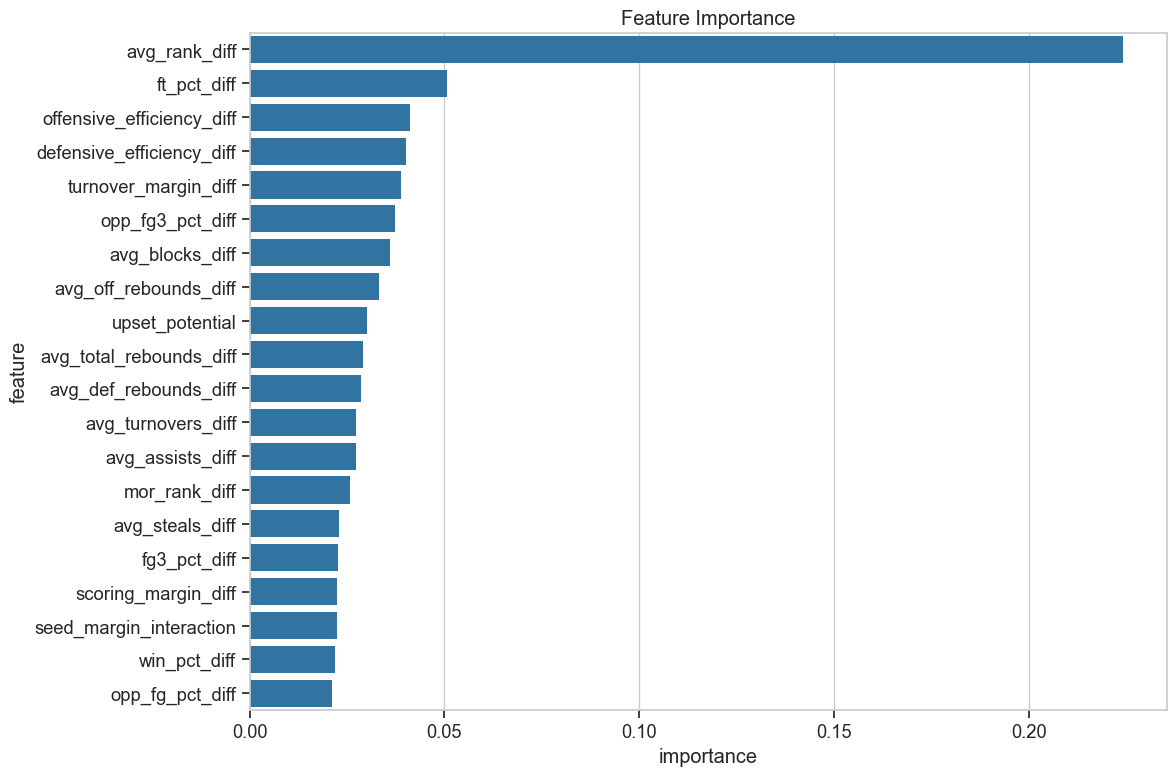

Model saved to models/march_madness_model.pkl

Evaluating model performance on all data...
Log Loss: 0.2740
ROC AUC: 0.9668

Confusion Matrix:
[[856  78]
 [ 67 867]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       934
           1       0.92      0.93      0.92       934

    accuracy                           0.92      1868
   macro avg       0.92      0.92      0.92      1868
weighted avg       0.92      0.92      0.92      1868



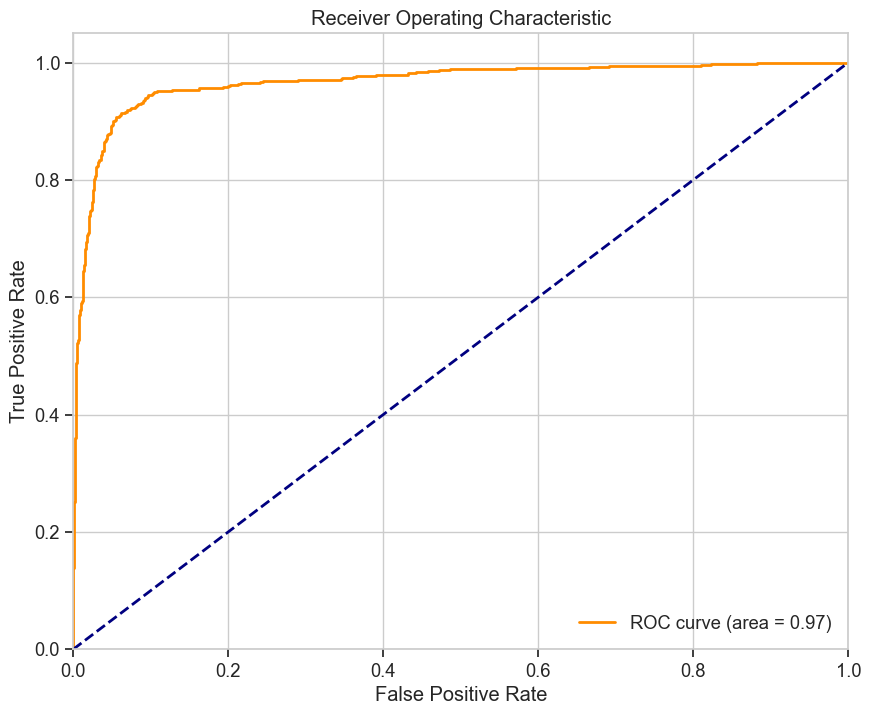

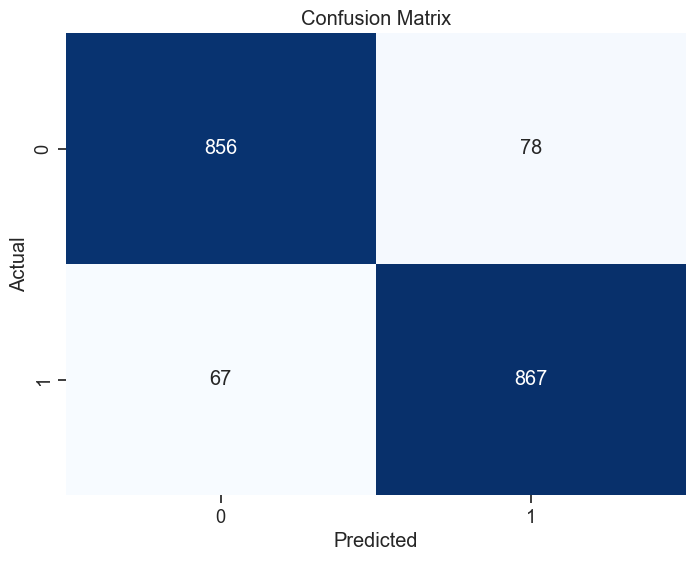

In [7]:
# Train the model
print("Training the prediction model...")
model_dict = train_model(tournament_features)

# Save the trained model
model_path = os.path.join(MODEL_DIR, "march_madness_model.pkl")
save_model(model_dict, model_path)

# Additional evaluation
print("\nEvaluating model performance on all data...")
eval_results = evaluate_model_performance(model_dict, tournament_features)

# 6. Hyperparameter Tuning (Optional)

If desired, we can perform hyperparameter tuning to optimize the model. This can take some time to run.

In [8]:
# Comment out this cell if you want to skip tuning
'''
# Define parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 0.9, 1.0]
}

# Tune model
tuned_model_dict = tune_model(tournament_features, param_grid=param_grid, cv=5)

# Save tuned model
tuned_model_path = os.path.join(MODEL_DIR, "tuned_march_madness_model.pkl")
save_model(tuned_model_dict, tuned_model_path)

# Use tuned model for predictions
model_dict = tuned_model_dict
'''

'\n# Define parameter grid for tuning\nparam_grid = {\n    \'n_estimators\': [100, 200, 300],\n    \'learning_rate\': [0.05, 0.1, 0.15],\n    \'max_depth\': [3, 5, 7],\n    \'min_samples_split\': [2, 5],\n    \'subsample\': [0.8, 0.9, 1.0]\n}\n\n# Tune model\ntuned_model_dict = tune_model(tournament_features, param_grid=param_grid, cv=5)\n\n# Save tuned model\ntuned_model_path = os.path.join(MODEL_DIR, "tuned_march_madness_model.pkl")\nsave_model(tuned_model_dict, tuned_model_path)\n\n# Use tuned model for predictions\nmodel_dict = tuned_model_dict\n'

# 7. Tournament Prediction

Now let's generate predictions for the current NCAA tournament season.

In [ ]:
# Prepare tournament matchups for prediction
print("Preparing tournament matchups for prediction...")
prediction_season = 2025  # Current season
matchups = prepare_tournament_matchups(data, season=prediction_season)

Preparing tournament matchups for prediction...
Using seeds from 2024 season for demonstration purposes


ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

: 